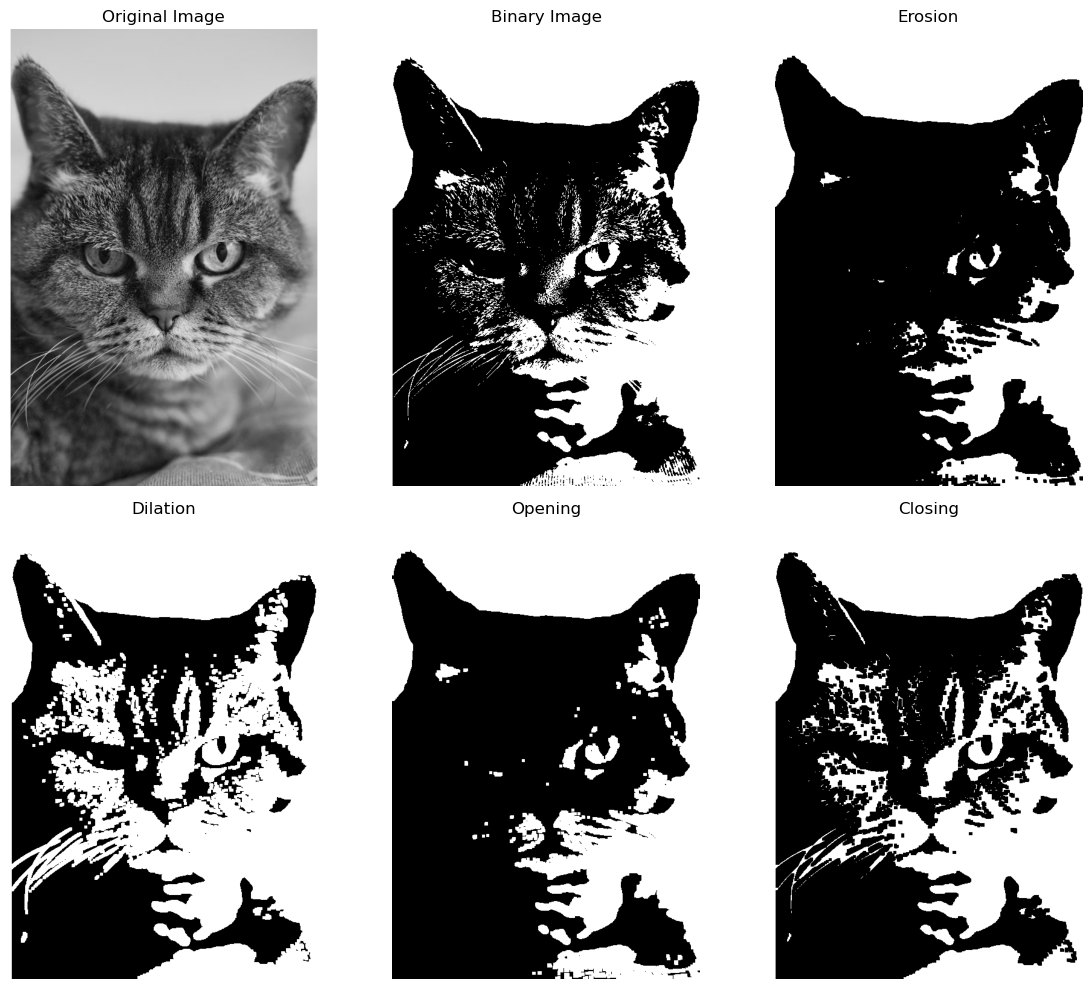

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read Image
image = cv2.imread("cat.png", cv2.IMREAD_GRAYSCALE)


# Convert image to binary
_, binary = cv2.threshold(
    image,
    127,
    255,
    cv2.THRESH_BINARY
)

# Create Structuring Element
kernel = np.ones((5, 5), np.uint8)

# 1. Erosion
erosion = cv2.erode(
    binary,
    kernel,
    iterations=1
)

# 2. Dilation
dilation = cv2.dilate(
    binary,
    kernel,
    iterations=1
)

# 3. Opening
# Opening = Erosion followed by Dilation
opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)


# 4. Closing
# Closing = Dilation followed by Erosion
closing = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

# Display Results
plt.figure(figsize=(12, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(erosion, cmap="gray")
plt.title("Erosion")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(dilation, cmap="gray")
plt.title("Dilation")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(opening, cmap="gray")
plt.title("Opening")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(closing, cmap="gray")
plt.title("Closing")
plt.axis("off")

plt.tight_layout()
plt.show()

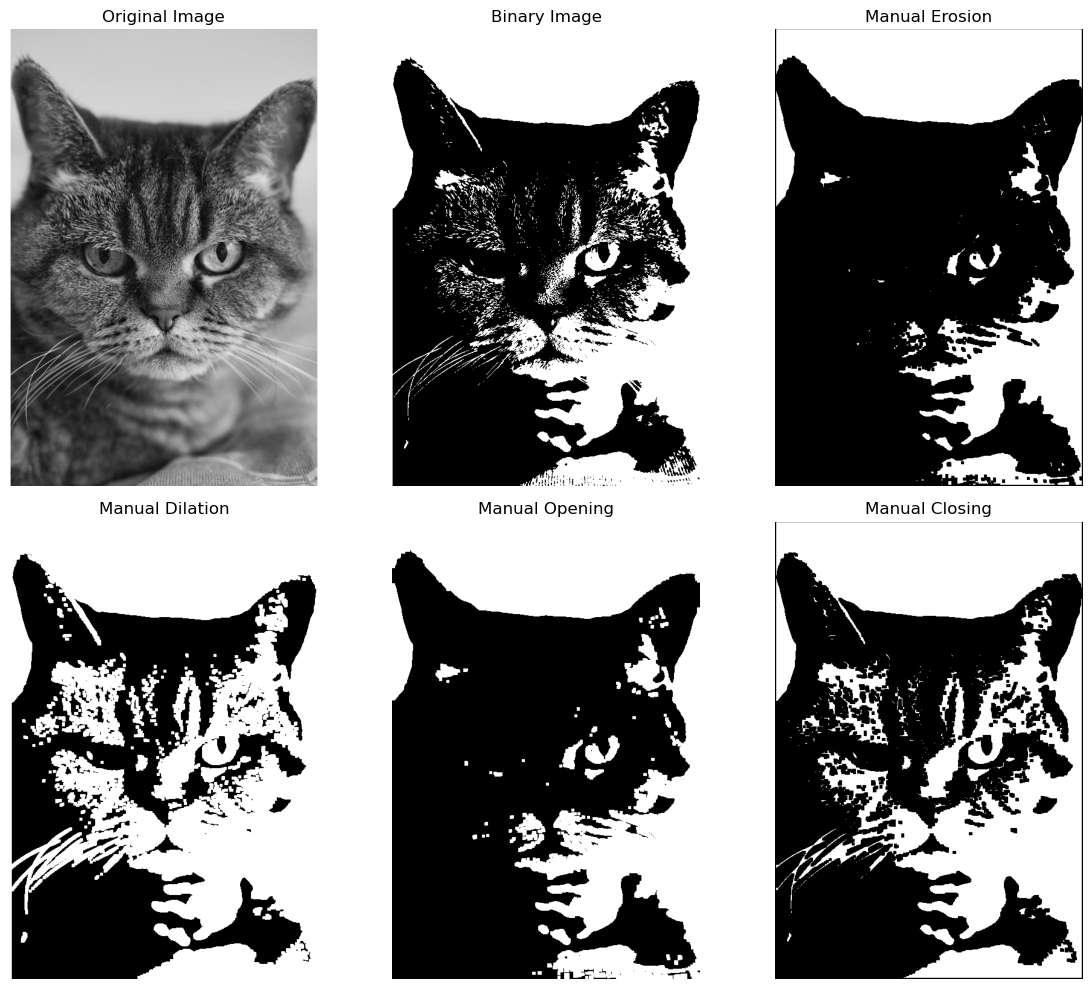

In [2]:

# Manual Morphological Operations (without OpenCV morphology functions)
def manual_erosion(img, kernel):
    img = np.asarray(img)
    kernel = np.asarray(kernel)
    h, w = img.shape
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2
    result = np.zeros_like(img, dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            valid = True
            for m in range(kh):
                for n in range(kw):
                    if kernel[m, n] == 0:
                        continue
                    rr = i + m - pad_h
                    cc = j + n - pad_w
                    if rr < 0 or rr >= h or cc < 0 or cc >= w:
                        valid = False
                        break
                    if img[rr, cc] == 0:
                        valid = False
                        break
                if not valid:
                    break
            if valid:
                result[i, j] = 255
    return result


def manual_dilation(img, kernel):
    img = np.asarray(img)
    kernel = np.asarray(kernel)
    h, w = img.shape
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2
    result = np.zeros_like(img, dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            for m in range(kh):
                for n in range(kw):
                    if kernel[m, n] == 0:
                        continue
                    rr = i + m - pad_h
                    cc = j + n - pad_w
                    if rr < 0 or rr >= h or cc < 0 or cc >= w:
                        continue
                    if img[rr, cc] > 0:
                        result[i, j] = 255
                        break
                if result[i, j] == 255:
                    break
    return result


def manual_opening(img, kernel):
    return manual_dilation(manual_erosion(img, kernel), kernel)


def manual_closing(img, kernel):
    return manual_erosion(manual_dilation(img, kernel), kernel)


# Use same binary image from previous cell
kernel = np.ones((5, 5), dtype=np.uint8)

manual_erosion_result = manual_erosion(binary, kernel)
manual_dilation_result = manual_dilation(binary, kernel)
manual_opening_result = manual_opening(binary, kernel)
manual_closing_result = manual_closing(binary, kernel)

plt.figure(figsize=(12, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(manual_erosion_result, cmap="gray")
plt.title("Manual Erosion")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(manual_dilation_result, cmap="gray")
plt.title("Manual Dilation")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(manual_opening_result, cmap="gray")
plt.title("Manual Opening")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(manual_closing_result, cmap="gray")
plt.title("Manual Closing")
plt.axis("off")

plt.tight_layout()
plt.show()
